# Synthetic Benchmark datasets


In [39]:
library(tidyverse)
library(ggplot2)

In [7]:
dt <- read_tsv("../../assembly/qc/qc_full.tsv", show_col_types = FALSE)
head(dt)

metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
Number of mapped sequences,59,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of primary alignments,1429,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of secondary alignments,102,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of primary alignments with >65535 CIGAR operations,0,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of bases in mapped sequences,64585949,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA
Number of mapped bases,63548451,haplotype1,phased_gfase,published_chr19_duplex15x,stat,NA


Transform some of the values:

A transcript is considered to be single-copy (SC) if it has only one hit; otherwise it is considered multi-copy (MC). We do the same for the assembly and then compute the fraction of missing multi-copy gene as

    MMC = 1 - |{MCinASM} ∩ {MCinREF}| / |{MCinREF}|

In the ideal case of a perfect assembly, %MMC should be zero.

In [158]:
dt_mmc <- dt %>%
  # First calculate MMC as before
  filter(metric %in% c("ref.dup_cnt", "asm.dup_cnt")) %>%
  pivot_wider(
    names_from = metric,
    values_from = value,
    values_fill = list(value = 0)
  ) %>%
  group_by(asm_name, haplotype, chromosome, source, asm_method) %>%
  summarise(
    ref_mc = sum(ref.dup_cnt),
    asm_mc = sum(asm.dup_cnt),
    value = 1 - asm_mc/ref_mc,
    .groups = 'drop'
  ) %>% 
  select( -ref_mc, -asm_mc) %>%
  mutate(metric = "MMC")

  head(dt_mmc)

asm_name,haplotype,chromosome,source,asm_method,value,metric
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
TUE_01,haplotype1,NA,asmgene,phased_gfase,0.3923706,MMC
TUE_01,haplotype1,NA,asmgene,phased_verkko,0.1968665,MMC
TUE_01,haplotype2,NA,asmgene,phased_gfase,0.3828338,MMC
TUE_01,haplotype2,NA,asmgene,phased_verkko,0.2588556,MMC
published_chr19_combined35x,haplotype1,NA,asmgene,phased_gfase,0.0000000,MMC
published_chr19_combined35x,haplotype1,NA,asmgene,phased_verkko,1.0000000,MMC


In [169]:
# Calculate genome completeness
dt_completeness <- dt %>%
  filter(source == "asmgene") %>%
  group_by(asm_name, haplotype, chromosome, source, asm_method) %>%
  summarise(
    complete = sum(value[metric == "asm.full_sgl"]),
    total = sum(value[metric == "ref.full_sgl"]),
    value = (complete/total) * 100,
    .groups = 'drop'
  ) %>%
  select( -complete, -total) %>%
  mutate(metric = "genome_completeness")

head(dt_completeness)

asm_name,haplotype,chromosome,source,asm_method,value,metric
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
TUE_01,haplotype1,NA,asmgene,phased_gfase,85.02686,genome_completeness
TUE_01,haplotype1,NA,asmgene,phased_verkko,89.42632,genome_completeness
TUE_01,haplotype2,NA,asmgene,phased_gfase,84.85797,genome_completeness
TUE_01,haplotype2,NA,asmgene,phased_verkko,93.51847,genome_completeness
published_chr19_combined35x,haplotype1,NA,asmgene,phased_gfase,97.33840,genome_completeness
published_chr19_combined35x,haplotype1,NA,asmgene,phased_verkko,97.08492,genome_completeness


In [172]:
# Combine both metrics with reduced original dataset
dt_reduced <- bind_rows(
  dt %>%
    filter(source != "asmgene"),
  dt_completeness,
  dt_mmc 
)

In [174]:
# Extract duplication/insertion values into a separate tibble

### Compare duplex to herro

In [170]:
dt_herro_vs_duplex <- dt_reduced %>%
  filter(str_detect(asm_name, "published")) %>%
  filter(!str_detect(asm_name, "nopolish")) %>%
  filter(asm_method=="phased_verkko") %>%
  mutate(
    seq_type = case_when(
      str_detect(asm_name, "duplex") ~ "duplex",
      str_detect(asm_name, "herro") ~ "herro",
      TRUE ~ NA_character_
    ),
    asm_name = str_remove(asm_name, "duplex|herro") %>%
        str_replace("__", "_") %>%
        str_remove_all("_$")
  )

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”


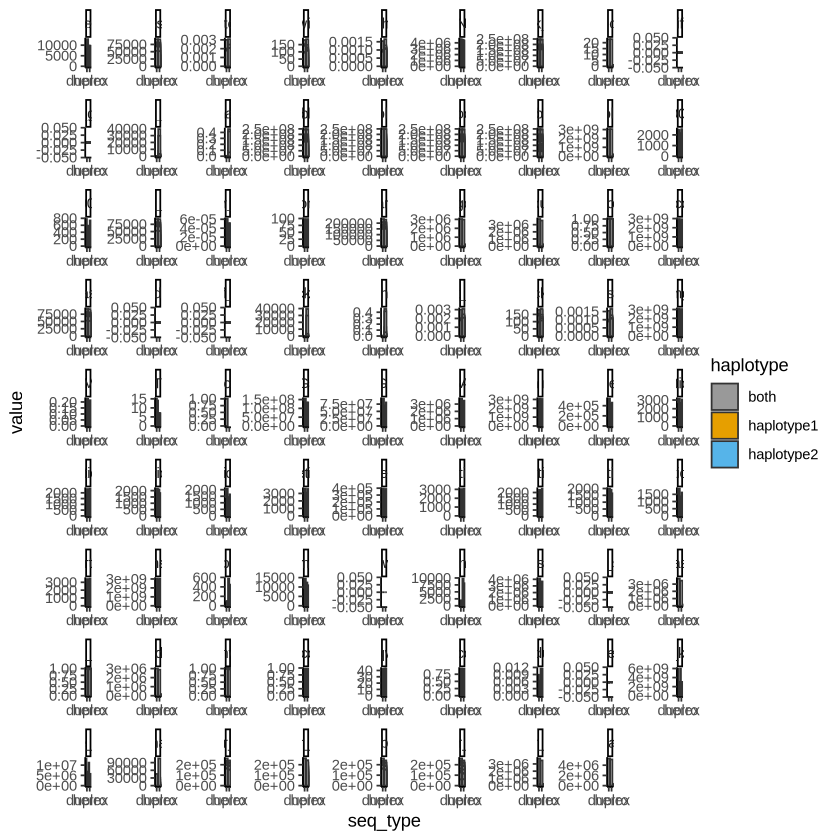

In [164]:
dt_herro_vs_duplex %>% 
    filter(asm_name == "published") %>%
    ggplot(aes(x = seq_type, y = value, fill = haplotype)) + 
        facet_wrap(~metric, scales = "free") + 
        geom_bar(stat = "identity",position = "dodge", col = "grey20") +
        # Okabe-Ito palette (colorblind friendly)
        scale_fill_manual(values = c("#999999", "#E69F00", "#56B4E9", "#009E73", "#F0E442")) +
        theme_classic()

In [165]:

dt_herro_vs_duplex_cat_chr <- dt_herro_vs_duplex %>% 
    filter(asm_name == "published") %>%
    group_by(seq_type, metric, haplotype) %>%
    summarise(value = sum(value, na.rm = TRUE), .groups = 'drop')

In [167]:
dt_herro_vs_duplex %>%
  filter(asm_name == "published") %>%
  group_by(seq_type, metric, haplotype, source) %>%
  summarise(value = sum(value, na.rm = TRUE), .groups = 'drop') %>%
  mutate(
    formatted_value = case_when(
      metric == "NG50" ~ paste0(round(value/1e6, 2), " Mb"),
      metric == "qv" ~ as.character(round(value, 2)),
      metric %in% c("all_switch_rate", "switch_rate") ~ paste0(round(value * 100, 2), "%"),
      TRUE ~ as.character(round(value, 2))
    )
  ) %>%
  select(-value) %>%  # Remove original value column
  pivot_wider(
    names_from = seq_type, 
    values_from = formatted_value
  ) %>%
  arrange(source, metric, haplotype) %>%
  knitr::kable()



|metric                                                    |haplotype  |source            |duplex        |herro        |
|:---------------------------------------------------------|:----------|:-----------------|:-------------|:------------|
|MMC                                                       |haplotype1 |asmgene           |0.23          |0.21         |
|MMC                                                       |haplotype2 |asmgene           |0.23          |0.21         |
|genome_completeness                                       |haplotype1 |asmgene           |94.41         |94.16        |
|genome_completeness                                       |haplotype2 |asmgene           |98.14         |98.09        |
|#breaks                                                   |haplotype1 |asmstat           |8420          |9842         |
|#breaks                                                   |haplotype2 |asmstat           |12855         |9734         |
|AUNGA                        

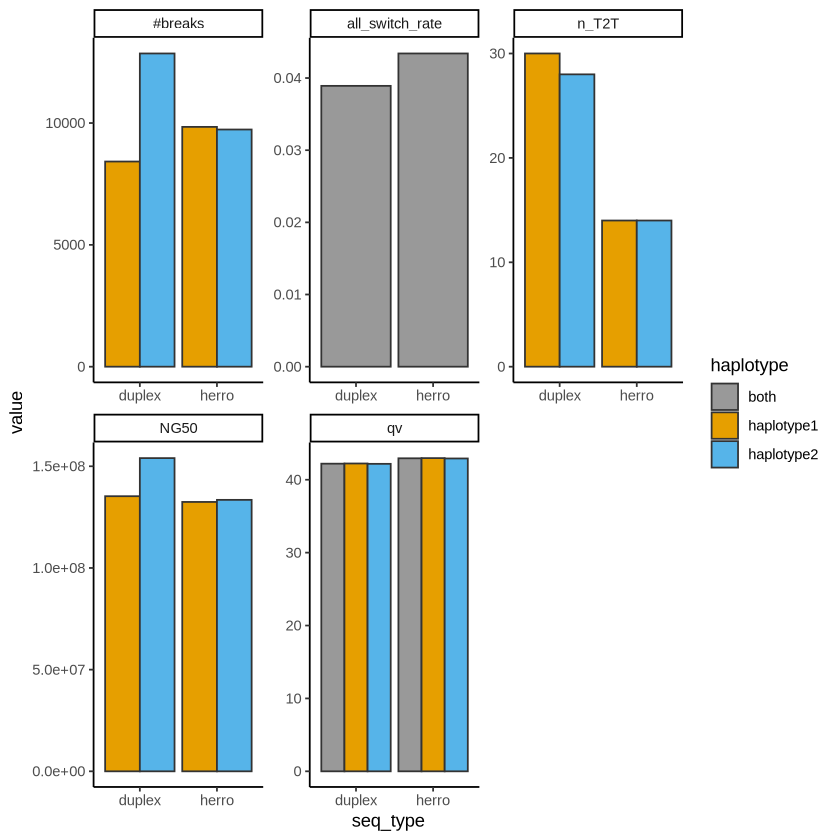

In [127]:
dt_herro_vs_duplex_cat_chr  %>% 
    filter(metric %in% c('NG50', 'n_T2T', 'qv', 'all_switch_rate', '#breaks', 'MMC')) %>%
    ggplot(aes(x = seq_type, y = value, fill = haplotype)) + 
        facet_wrap(~metric, scales = "free") + 
        geom_bar(stat = "identity",position = "dodge", col = "grey20") +
        # Okabe-Ito palette (colorblind friendly)
        scale_fill_manual(values = c("#999999", "#E69F00", "#56B4E9", "#009E73", "#F0E442")) +
        theme_classic()